# Script for training

Last version 05/27/2025
Need to use requirement.txt : 

absl-py==2.3.0
certifi==2022.12.7
charset-normalizer==2.1.1
contourpy==1.3.2
cycler==0.12.1
filelock==3.18.0
fonttools==4.58.4
fsspec==2025.5.1
grpcio==1.73.1
idna==3.4
Jinja2==3.1.6
joblib==1.5.1
kiwisolver==1.4.8
Markdown==3.8.2
MarkupSafe==3.0.2
matplotlib==3.7.3
mpmath==1.3.0
networkx==3.5
numpy==1.24.4
packaging==25.0
pandas==2.0.3
pillow==11.2.1
protobuf==4.24.3
pyparsing==3.2.3
python-dateutil==2.8.2
pytorch-ignite==0.4.12
pytz==2025.2
requests==2.28.1
scikit-learn==1.3.1
scipy==1.10.1
six==1.17.0
sympy==1.12
tensorboard==2.19.0
tensorboard-data-server==0.7.2
threadpoolctl==3.6.0
torch==2.0.1
torchaudio==2.0.2
torchvision==0.15.2
tqdm==4.67.1
typing_extensions==4.8.0
tzdata==2025.2
urllib3==1.26.13
Werkzeug==3.1.3


### Library Imports and Environment Setup

In [1]:
#Misc librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

#Pytorch main librairies
from PIL import Image
import torch

import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau

#High-level ignite librairies for callbacks
from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Loss, RunningAverage, MeanSquaredError
from ignite.handlers import ModelCheckpoint, EarlyStopping
from ignite.contrib.metrics.regression import MedianAbsoluteError, MeanAbsoluteRelativeError, MeanError, R2Score

#Visualization
import logging
from ignite.contrib.handlers.tensorboard_logger import *
from ignite.contrib.handlers.param_scheduler import LRScheduler

#Seeding for reproducibility
torch.manual_seed(42)
np.random.seed(42)

<positron-console-cell-1>:29: DeprecationWarning: /Users/nmouquet/Documents/SCIENCE/Submitted/23_BELEZARUAS/BELLEZARUAS/DEEP_final/.conda/lib/python3.11/site-packages/ignite/contrib/handlers/param_scheduler.py has been moved to /ignite/handlers/param_scheduler.py and will be removed in version 0.6.0.
 Please refer to the documentation for more details.


### Loading and Preprocessing the Aesthetic Dataset

In [2]:
class EsthDataset(torch.utils.data.Dataset):
  def __init__(self, path, transforms=None):
    # import and initialize dataset
    data = pd.read_csv(path, header=None, sep = ",")
    data.columns = ["names", "scores"]
    
    self.X = data["names"].values
    self.Y = data["scores"].values[:, np.newaxis].astype(np.float32)
    self.transforms = transforms
    
  def __getitem__(self, idx):
    # get item by index
    im = Image.open('../data/BIG_FILES/Images/png_sq/'+ self.X[idx] + ".png")
    
    if self.transforms :
        im = self.transforms(im)
        
        return im, self.Y[idx]
    
    return im.ToTensor(), self.Y[idx]
  
  def __len__(self):
    # returns length of data
    return len(self.X)

### Creating model, loss and optimizer


In [3]:
model = models.resnet50(pretrained=True)

/Users/nmouquet/Documents/SCIENCE/Submitted/23_BELEZARUAS/BELLEZARUAS/DEEP_final/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/nmouquet/Documents/SCIENCE/Submitted/23_BELEZARUAS/BELLEZARUAS/DEEP_final/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Training Configuration and Hyperparameter Setup

In [4]:
# hyperparameters
resize = False
learning_rate = 1e-2 #between 1e-1 and 1e-4 depending
batch_size = 16
num_epochs_warmup = 5
num_epochs = 350
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)
lr_schedule = True
add_dropout = True
dropout=0.5
freeze = True

# to use GPU uncomment the cuda line if you run on GPU and comment the second line (which is made to run on mac)
#device = torch.device("cuda")
device = "mps" if torch.backends.mps.is_available() else "cpu"

#Log and weights saving
log_dir = './logs/'
save_dir = './saved_models/'

#Datasets : normalized or not
train_path = "../results/deep/beleza_train.txt"
val_path = '../results/deep/beleza_val.txt'
test_path = '../results/deep/beleza_test.txt'

#import os 
#print(os.getcwd())

### Setting data augmentation process according to the train or val/test splits


In [5]:
if resize :
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize((224,224)),
            transforms.RandomRotation(30),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.392, 0.298, 0.203], [0.192, 0.167, 0.140])
        ]),
        'val': transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize([0.392, 0.298, 0.203], [0.192, 0.167, 0.140])
        ]),
        'test': transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize([0.392, 0.298, 0.203], [0.192, 0.167, 0.140])
        ])
    }
    
else : 
    data_transforms = {
    'train': transforms.Compose([
        transforms.RandomRotation(30),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomVerticalFlip(0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.392, 0.298, 0.203], [0.192, 0.167, 0.140])
    ]),
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.392, 0.298, 0.203], [0.192, 0.167, 0.140])
    ]),
    'test': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.392, 0.298, 0.203], [0.192, 0.167, 0.140])
    ])
}

### create dataset instance

In [6]:
esthdataset_train = EsthDataset(train_path, transforms = data_transforms['train'])
esthdataset_val = EsthDataset(val_path, transforms = data_transforms['val'])
esthdataset_test = EsthDataset(test_path, transforms = data_transforms['test'])

### create dataloader instance


In [7]:
train_loader = torch.utils.data.DataLoader(esthdataset_train, batch_size = batch_size, shuffle = True, pin_memory=True)
val_loader = torch.utils.data.DataLoader(esthdataset_val, batch_size = batch_size, shuffle = True, pin_memory = True)
test_loader = torch.utils.data.DataLoader(esthdataset_test, batch_size = batch_size, shuffle = True, pin_memory = True)

### Model Adaptation and Final Layer Customization


In [8]:
#Freeze all weights
for param in model.parameters():
    param.requires_grad = False

# Replace the last fully-connected layer
# Parameters of newly constructed modules have requires_grad=True by default
if add_dropout :
    model.fc = nn.Sequential(
    nn.Dropout(dropout),
    nn.Linear(2048, 1)
)
else :
    model.fc = nn.Linear(512, 1)


model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### warm-up for a few epochs


In [ ]:
for i in tqdm(range(num_epochs_warmup)):
  
  for (x, y) in train_loader:
    x, y = x.float().to(device), y.to(device)
    outputs = model(x)
    loss = criterion(outputs, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  0%|          | 0/5 [00:00<?, ?it/s]

### Unfreeze model parameters


In [10]:
if not freeze :
    for param in model.parameters():
        param.requires_grad = True
        
else :
    for name, param in model.named_parameters():
        if "layer4" in str(name):
            param.requires_grad = True

for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.0.conv3.weight False
layer1.0.bn3.weight False
layer1.0.bn3.bias False
layer1.0.downsample.0.weight False
layer1.0.downsample.1.weight False
layer1.0.downsample.1.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.1.conv3.weight False
layer1.1.bn3.weight False
layer1.1.bn3.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer1.2.conv3.weight False
layer1.2.bn3.weight False
layer1.2.bn3.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2

### creating trainer,evaluator


In [11]:
# creating trainer,evaluator
trainer = create_supervised_trainer(model, optimizer, criterion, device=device)
metrics = {
    'me':MeanError(),
    'mse':Loss(criterion),
    'mare':MeanAbsoluteRelativeError(),
    'medae':MedianAbsoluteError(),
    'r2':R2Score()
}
train_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=metrics, device=device)
training_history = {'mare':[],'mse':[],'me':[], 'medae':[], 'r2':[]}
validation_history = {'mare':[],'mse':[],'me':[], 'medae':[], 'r2':[]}
last_epoch = []

RunningAverage(output_transform=lambda x: x).attach(trainer, 'mare')

### Training Monitoring, Early Stopping, and Checkpointing

In [12]:
#Early stopping callback
def score_function(trainer):
    val_evaluator.run(val_loader)
    val_loss = val_evaluator.state.metrics['mse']
    return -val_loss

handler = EarlyStopping(patience=10, score_function=score_function, trainer=trainer)
trainer.add_event_handler(Events.COMPLETED, handler)

#Model checkpoints
checkpointer = ModelCheckpoint(save_dir, 'Chckpt', score_function = score_function, n_saved=2, 
                               create_dir=True, save_as_state_dict=True, require_empty=False)
trainer.add_event_handler(Events.EPOCH_COMPLETED, checkpointer, {'ResNet50': model})

#Learning rate scheduler
if lr_schedule :
    lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience = 100, threshold=0.01,
                                     threshold_mode = 'rel',verbose = True)
    trainer.add_event_handler(Events.EPOCH_COMPLETED, lambda engine: lr_scheduler.step(val_evaluator.state.metrics['mse']))

#Logs to display during training
@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    mean_abs_rel_err = metrics['mare']*100
    loss = metrics['mse']
    r2 = metrics['r2']
    medae = metrics['medae']
    last_epoch.append(0)
    training_history['mare'].append(mean_abs_rel_err)
    training_history['mse'].append(loss)
    training_history['r2'].append(r2)
    training_history['medae'].append(medae)
    print("Training Results - Epoch: {}  Mean absolute relative error: {:.2f} Avg loss: {:.2f} R2 score : {:.2f}"
          .format(trainer.state.epoch, mean_abs_rel_err, loss, r2))

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    mean_abs_rel_err = metrics['mare']*100
    loss = metrics['mse']
    r2 = metrics['r2']
    medae = metrics['medae']
    validation_history['mare'].append(mean_abs_rel_err)
    validation_history['mse'].append(loss)
    validation_history['r2'].append(r2)
    validation_history['medae'].append(medae)
    print("Validation Results - Epoch: {}  Mean absolute relative error: {:.2f} Avg loss: {:.2f} R2 score : {:.2f}"
          .format(trainer.state.epoch, mean_abs_rel_err, loss, r2))
    print("~"*60 + "\n")

### TensorBoard Logging for Training and Evaluation Metrics

In [13]:
#Tensorboard stuff

tb_logger = TensorboardLogger(log_dir=log_dir)

tb_logger.attach(
    trainer,
    log_handler=OutputHandler(
        tag="training", output_transform=lambda loss: {"batchloss": loss}, metric_names="all"
    ),
    event_name=Events.ITERATION_COMPLETED(every=100),
)

tb_logger.attach(
    train_evaluator,
    log_handler=OutputHandler(tag="training", metric_names=["mse", "mare", "medae", "me"]),
    event_name=Events.EPOCH_COMPLETED,
)

tb_logger.attach(
    val_evaluator,
    log_handler=OutputHandler(tag="validation", metric_names=["mse", "mare", "medae", "me"]),
    event_name=Events.EPOCH_COMPLETED,
)

tb_logger.attach(
    trainer, log_handler=OptimizerParamsHandler(optimizer), event_name=Events.EPOCH_COMPLETED(every=10)
)

### Training the neural network


In [14]:
trainer.run(train_loader, max_epochs=num_epochs)

Training Results - Epoch: 1  Mean absolute relative error: 125.32 Avg loss: 3977522.50 R2 score : -37.81
Validation Results - Epoch: 1  Mean absolute relative error: 127.67 Avg loss: 4184516.06 R2 score : -36.14
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Training Results - Epoch: 2  Mean absolute relative error: 98.99 Avg loss: 2287234.61 R2 score : -21.32
Validation Results - Epoch: 2  Mean absolute relative error: 98.92 Avg loss: 2277642.92 R2 score : -19.22
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Training Results - Epoch: 3  Mean absolute relative error: 97.56 Avg loss: 2213949.82 R2 score : -20.61
Validation Results - Epoch: 3  Mean absolute relative error: 97.40 Avg loss: 2198751.75 R2 score : -18.52
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Training Results - Epoch: 4  Mean absolute relative error: 96.74 Avg loss: 2175268.35 R2 score : -20.23
Validation Results - Epoch: 4  Mean absolute relative error: 96.41 Avg loss: 2

State:
	iteration: 5700
	epoch: 300
	epoch_length: 19
	max_epochs: 300
	output: 10447.03125
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

### Plot the loss, check model quality

Saved plot to results/training_validation_metrics.tiff


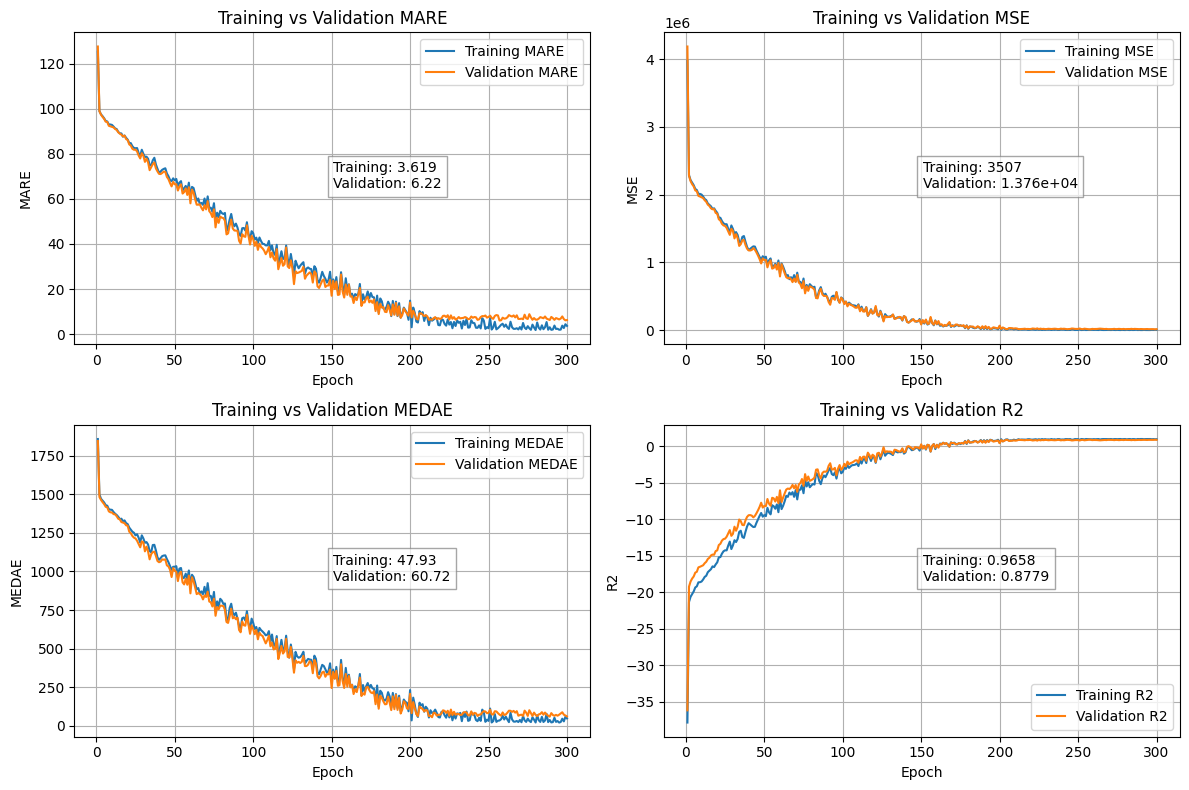

In [15]:
import matplotlib.pyplot as plt

# Metrics to plot
metrics = ['mare', 'mse', 'medae', 'r2']

num_epochs = len(next(iter(training_history.values())))
epochs = list(range(1, num_epochs + 1))

# Create figure with subplots: 2 rows × 2 columns
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    train_values = training_history[metric]
    val_values = validation_history[metric]
    
    ax = axes[i]
    ax.plot(epochs, train_values, label=f"Training {metric.upper()}")
    ax.plot(epochs, val_values, label=f"Validation {metric.upper()}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Training vs Validation {metric.upper()}")
    ax.legend()
    ax.grid(True)
    
    # Add text with last epoch values
    last_train = train_values[-1]
    last_val = val_values[-1]
    
    text_str = f"Training: {last_train:.4g}\nValidation: {last_val:.4g}"
    
    # Place text roughly in the middle of the plot
    x_mid = epochs[len(epochs)//2]
    y_mid = (max(train_values + val_values) + min(train_values + val_values)) / 2
    
    ax.text(
        x_mid, y_mid,
        text_str,
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
    )

# Hide unused subplots if fewer than 4 metrics
for j in range(len(metrics), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save as TIFF
fig.savefig("results/training_validation_metrics.tiff", format='tiff', dpi=300)
print("Saved plot to results/training_validation_metrics.tiff")

In [16]:
# loading the saved model
def fetch_last_checkpoint_model_filename(model_save_path):
    import os
    checkpoint_files = os.listdir(model_save_path)
    checkpoint_files = [f for f in checkpoint_files if '.pt' in f]
    checkpoint_iter = [
        int(x.split('_')[2].split('.')[0])
        for x in checkpoint_files]
    last_idx = np.array(checkpoint_iter).argmax()
    return os.path.join(model_save_path, checkpoint_files[last_idx])

model.load_state_dict(torch.load(fetch_last_checkpoint_model_filename(save_dir)))
print("Model Loaded")

Model Loaded


In [17]:
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mean_error(y_true, y_pred): 
    return np.mean((y_true - y_pred))

MSE  : 4730.59
ME   : -59.57
MedAE: 60.77
MAPE : 0.04
R²   : 0.95
MAE  : 61.14


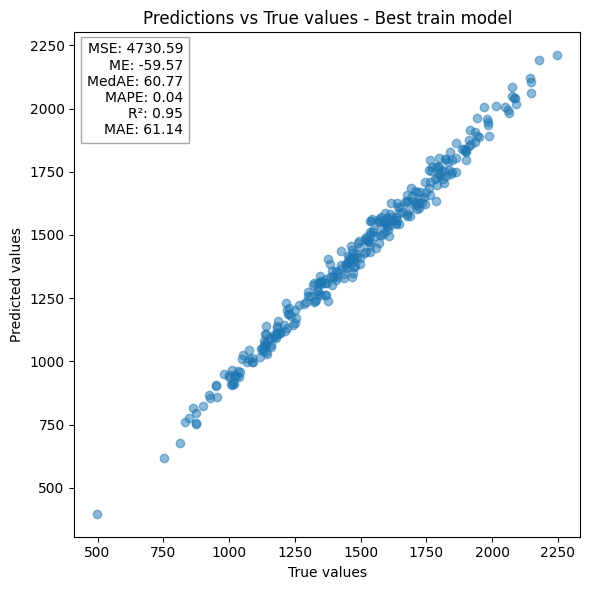

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error

# set model to evaluate mode
model.eval()

y_true = torch.tensor([], dtype=torch.float, device=device)
y_pred = torch.tensor([], device=device)

# deactivate autograd engine and reduce memory usage and speed up computations
with torch.no_grad():
    for data in train_loader:
        inputs = [i.to(device) for i in data[:-1]]
        labels = data[-1].to(device)

        outputs = model(*inputs)
        y_true = torch.cat((y_true, labels), 0)
        y_pred = torch.cat((y_pred, outputs), 0)

y_true = y_true.cpu().numpy().flatten()
y_pred = y_pred.cpu().numpy().flatten()

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
me = np.mean(y_pred - y_true)
medae = median_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

# Print metrics in console
print(f"MSE  : {mse:.2f}")
print(f"ME   : {me:.2f}")
print(f"MedAE: {medae:.2f}")
print(f"MAPE : {mape:.2f}")
print(f"R²   : {r2:.2f}")
print(f"MAE  : {mae:.2f}")

# Create scatter plot
f = plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Predictions vs True values - Best train model")

# Prepare metrics text
metrics_text = (
    f"MSE: {mse:.2f}\n"
    f"ME: {me:.2f}\n"
    f"MedAE: {medae:.2f}\n"
    f"MAPE: {mape:.2f}\n"
    f"R²: {r2:.2f}\n"
    f"MAE: {mae:.2f}"
)

# Place metrics text at top-right corner
plt.gca().text(
    0.215, 0.98,
    metrics_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.tight_layout()
plt.savefig("./results/best_train.jpg", dpi=300)
plt.show()

MSE  : 11829.83
ME   : 0.33
MedAE: 66.51
MAPE : 0.06
R²   : 0.89
MAE  : 82.17


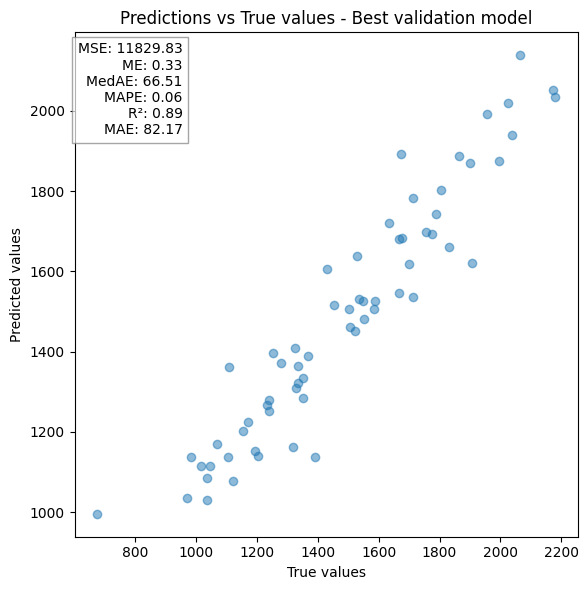

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error

# set model to evaluate mode
model.eval()

y_true = torch.tensor([], dtype=torch.float, device=device)
y_pred = torch.tensor([], device=device)

# deactivate autograd engine and reduce memory usage and speed up computations
with torch.no_grad():
    for data in val_loader:
        inputs = [i.to(device) for i in data[:-1]]
        labels = data[-1].to(device)

        outputs = model(*inputs)
        y_true = torch.cat((y_true, labels), 0)
        y_pred = torch.cat((y_pred, outputs), 0)

y_true = y_true.cpu().numpy().flatten()
y_pred = y_pred.cpu().numpy().flatten()

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
me = np.mean(y_pred - y_true)
medae = median_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

# Print metrics in console
print(f"MSE  : {mse:.2f}")
print(f"ME   : {me:.2f}")
print(f"MedAE: {medae:.2f}")
print(f"MAPE : {mape:.2f}")
print(f"R²   : {r2:.2f}")
print(f"MAE  : {mae:.2f}")

# Create scatter plot
f = plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Predictions vs True values - Best validation model")

# Prepare metrics text
metrics_text = (
    f"MSE: {mse:.2f}\n"
    f"ME: {me:.2f}\n"
    f"MedAE: {medae:.2f}\n"
    f"MAPE: {mape:.2f}\n"
    f"R²: {r2:.2f}\n"
    f"MAE: {mae:.2f}"
)

# Place metrics text at top-right corner
plt.gca().text(
    0.215, 0.98,
    metrics_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.tight_layout()
plt.savefig("./results/best_val.jpg", dpi=300)
plt.show()

MSE  : 14445.08
ME   : -54.82
MedAE: 84.95
MAPE : 0.06
R²   : 0.84
MAE  : 96.61


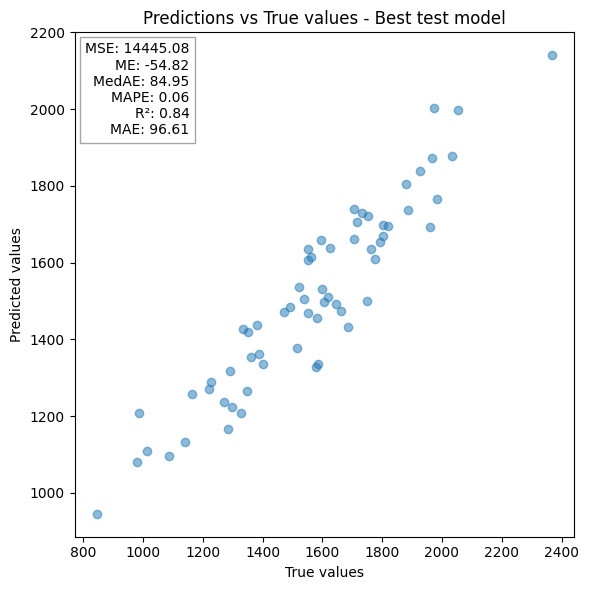

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error

# set model to evaluate mode
model.eval()

y_true = torch.tensor([], dtype=torch.float, device=device)
y_pred = torch.tensor([], device=device)

# deactivate autograd engine and reduce memory usage and speed up computations
with torch.no_grad():
    for data in test_loader:
        inputs = [i.to(device) for i in data[:-1]]
        labels = data[-1].to(device)

        outputs = model(*inputs)
        y_true = torch.cat((y_true, labels), 0)
        y_pred = torch.cat((y_pred, outputs), 0)

y_true = y_true.cpu().numpy().flatten()
y_pred = y_pred.cpu().numpy().flatten()

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
me = np.mean(y_pred - y_true)
medae = median_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

# Print metrics in console
print(f"MSE  : {mse:.2f}")
print(f"ME   : {me:.2f}")
print(f"MedAE: {medae:.2f}")
print(f"MAPE : {mape:.2f}")
print(f"R²   : {r2:.2f}")
print(f"MAE  : {mae:.2f}")

# Create scatter plot
f = plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Predictions vs True values - Best test model")

# Prepare metrics text
metrics_text = (
    f"MSE: {mse:.2f}\n"
    f"ME: {me:.2f}\n"
    f"MedAE: {medae:.2f}\n"
    f"MAPE: {mape:.2f}\n"
    f"R²: {r2:.2f}\n"
    f"MAE: {mae:.2f}"
)

# Place metrics text at top-right corner
plt.gca().text(
    0.23, 0.98,
    metrics_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.tight_layout()
plt.savefig("./results/best_test.jpg", dpi=300)
plt.show()